# File: 02_eda.ipynb

## Purpose
This notebook performs Exploratory Data Analysis (EDA) on the satellite dataset by examining distributions, identifying trends, and understanding relationships between key variables.

# Day 12

In [24]:
import pandas as pd
import matplotlib.pyplot as plt

In [25]:
df = pd.read_csv("../data/processed/current_catalog_cleaned.csv")

df.head()

,norad_id,name,object_type,satellite_constellation,altitude_km,altitude_category,orbital_band,congestion_risk,inclination,eccentricity,launch_year_estimate,days_in_orbit_estimate,orbit_lifetime_category,mean_motion,epoch,data_source,snapshot_date,country,last_seen
0,900,CALSPHERE 1,PAYLOAD,Other,975.794787,Low LEO,LEO-Polar,LOW,90.2213,0.002375,2024,0,<1yr,13.766495,2026-07-13 03:15:37.038240,celestrak,2026-07-13,US,2026-07-13
1,902,CALSPHERE 2,PAYLOAD,Other,1061.599445,Mid LEO,LEO-Polar,LOW,90.2347,0.001955,2024,0,<1yr,13.529023,2026-07-13 03:50:06.194688,celestrak,2026-07-13,US,2026-07-13
2,1361,LCS 1,PAYLOAD,Other,2787.866858,High LEO,MEO,LOW,32.1398,0.001237,2024,0,<1yr,9.893107,2026-07-13 05:22:30.480096,celestrak,2026-07-13,US,2026-07-13
3,1512,TEMPSAT 1,PAYLOAD,Other,1133.231902,Mid LEO,LEO-Polar,HIGH,89.9978,0.006993,2024,0,<1yr,13.335955,2026-07-13 11:40:59.394720,celestrak,2026-07-13,US,2026-07-13
4,1520,CALSPHERE 4A,PAYLOAD,Other,1123.157652,Mid LEO,LEO-Polar,HIGH,89.8990,0.007140,2024,0,<1yr,13.362829,2026-07-13 12:07:15.869856,celestrak,2026-07-13,US,2026-07-13


### Summary Statistics for mean_motion

In [26]:
# Summary statistics for mean_motion
print(df["mean_motion"].describe())

count    16649.000000
mean        14.431601
std          3.079388
min          0.073149
25%         15.027965
50%         15.275841
75%         15.343811
max         16.517224
Name: mean_motion, dtype: float64


### Distribution of mean_motion


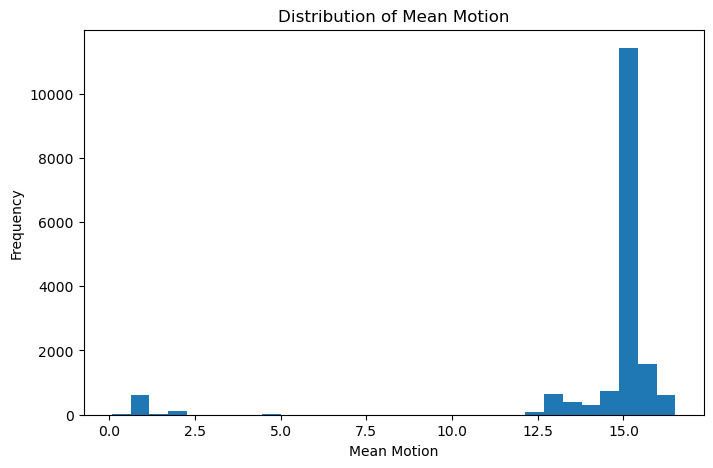

In [27]:
plt.figure(figsize=(8,5))

plt.hist(df["mean_motion"], bins=30)

plt.title("Distribution of Mean Motion")
plt.xlabel("Mean Motion")
plt.ylabel("Frequency")

plt.show()

### Country Analysis

In [28]:
# Top 10 countries by satellite count

country_counts = df["country"].value_counts().head(10)

print(country_counts)

country
US     12541
PRC     1475
UK       701
CIS      295
TBD      280
JPN      131
IT        87
FR        75
IND       74
ESA       70
Name: count, dtype: int64


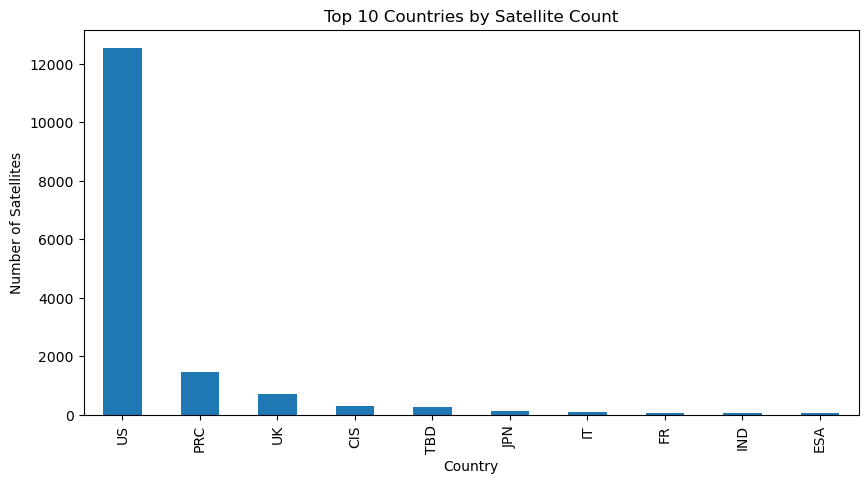

In [29]:
plt.figure(figsize=(10,5))

country_counts.plot(kind="bar")

plt.title("Top 10 Countries by Satellite Count")
plt.xlabel("Country")
plt.ylabel("Number of Satellites")

plt.show()

### Segment Analysis

- object_type

In [30]:
# Satellite count by object type
object_type_counts = df["object_type"].value_counts()

print(object_type_counts)

object_type
PAYLOAD        16011
UNKNOWN          624
ROCKET BODY       13
DEBRIS             1
Name: count, dtype: int64


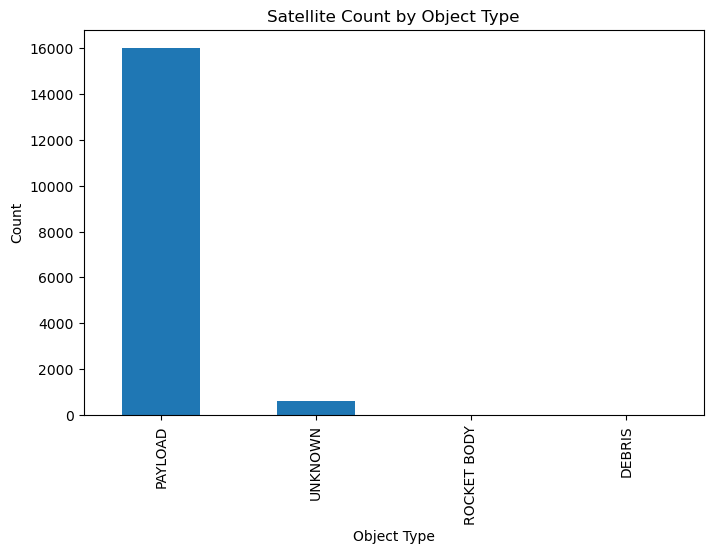

In [31]:
plt.figure(figsize=(8,5))

object_type_counts.plot(kind="bar")

plt.title("Satellite Count by Object Type")
plt.xlabel("Object Type")
plt.ylabel("Count")

plt.show()

- altitude_category

In [32]:
# Satellite count by altitude category
altitude_counts = df["altitude_category"].value_counts()

print(altitude_counts)

altitude_category
Very Low LEO    10536
Low LEO          4133
Mid LEO          1137
GEO               585
MEO               171
High LEO           44
Beyond GEO         43
Name: count, dtype: int64


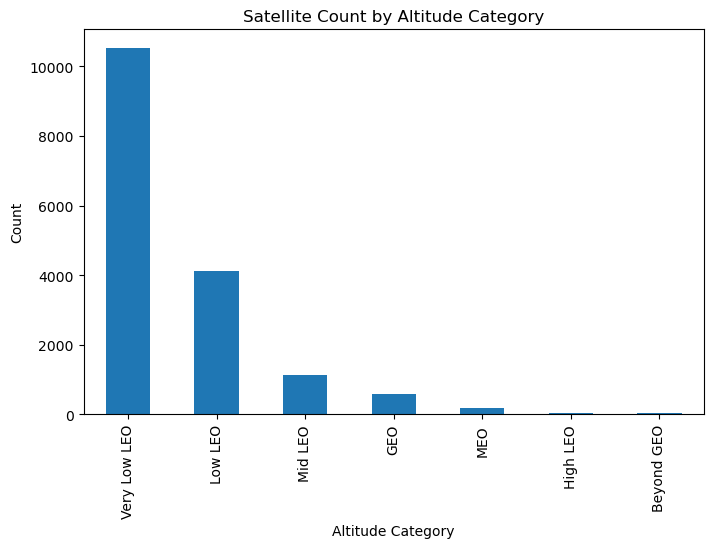

In [33]:
plt.figure(figsize=(8,5))

altitude_counts.plot(kind="bar")

plt.title("Satellite Count by Altitude Category")
plt.xlabel("Altitude Category")
plt.ylabel("Count")

plt.show()

- eccentricity

In [34]:
print(df["eccentricity"].describe())

count    16649.000000
mean         0.002705
std          0.039241
min          0.000003
25%          0.000117
50%          0.000166
75%          0.000324
max          0.908760
Name: eccentricity, dtype: float64


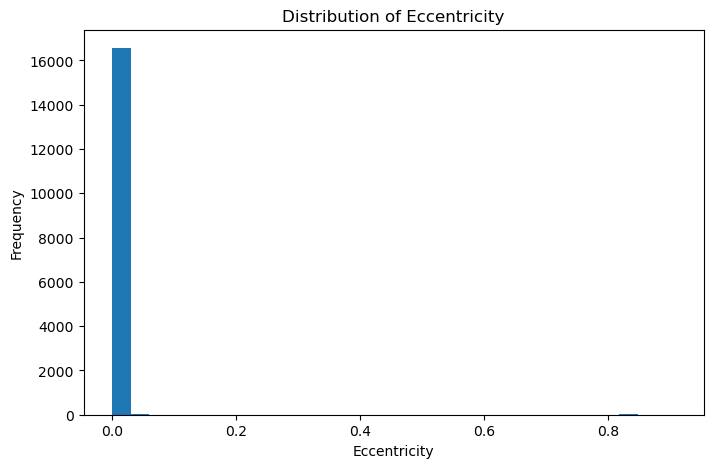

In [35]:
plt.figure(figsize=(8,5))

plt.hist(df["eccentricity"], bins=30)

plt.title("Distribution of Eccentricity")
plt.xlabel("Eccentricity")
plt.ylabel("Frequency")

plt.show()

### Derive Date Parts

- Launch Year

In [36]:
# Launch year distribution
print(df["launch_year_estimate"].value_counts().sort_index())

launch_year_estimate
2023      114
2024    16535
Name: count, dtype: int64


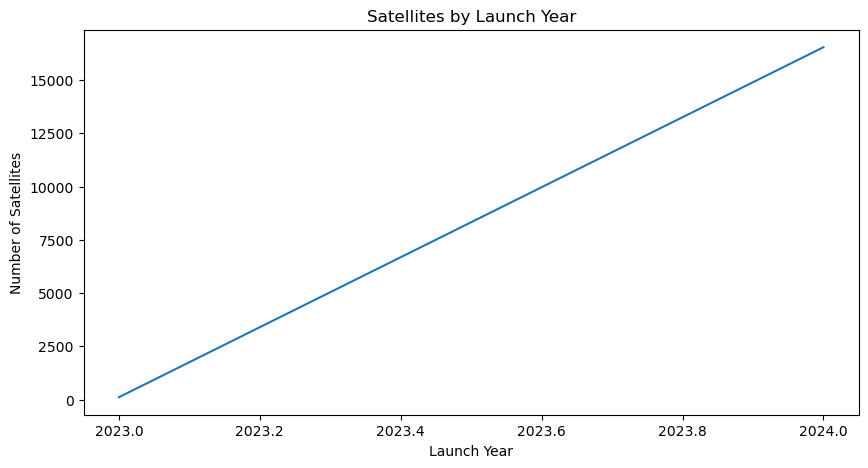

In [37]:
plt.figure(figsize=(10,5))

df["launch_year_estimate"].value_counts().sort_index().plot()

plt.title("Satellites by Launch Year")
plt.xlabel("Launch Year")
plt.ylabel("Number of Satellites")

plt.show()

- Days in Orbit

In [38]:
print(df["days_in_orbit_estimate"].describe())

count    16649.000000
mean         0.233347
std          1.164107
min         -2.000000
25%          0.000000
50%          0.000000
75%          0.000000
max         29.000000
Name: days_in_orbit_estimate, dtype: float64


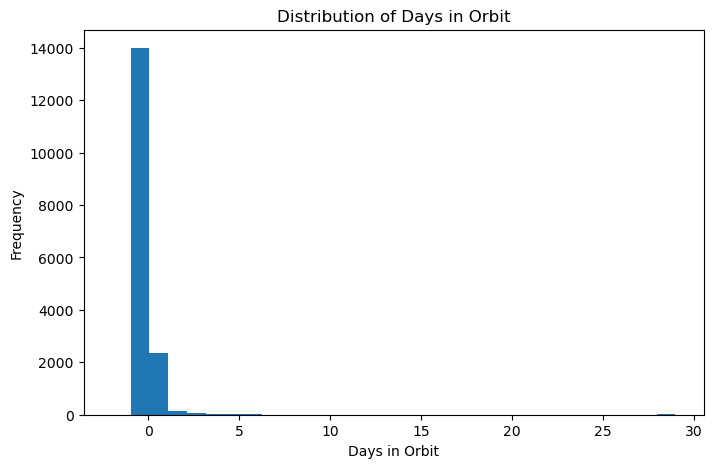

In [39]:
plt.figure(figsize=(8,5))

plt.hist(df["days_in_orbit_estimate"], bins=30)

plt.title("Distribution of Days in Orbit")
plt.xlabel("Days in Orbit")
plt.ylabel("Frequency")

plt.show()

# Day 13 OUtliers Analysis

- IQR Method

In [40]:
Q1 = df["mean_motion"].quantile(0.25)
Q3 = df["mean_motion"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_iqr = df[(df["mean_motion"] < lower_bound) | (df["mean_motion"] > upper_bound)]

print("Number of outliers (IQR):", len(outliers_iqr))
outliers_iqr.head()

Number of outliers (IQR): 3153


,norad_id,name,object_type,satellite_constellation,altitude_km,altitude_category,orbital_band,congestion_risk,inclination,eccentricity,launch_year_estimate,days_in_orbit_estimate,orbit_lifetime_category,mean_motion,epoch,data_source,snapshot_date,country,last_seen
0,900,CALSPHERE 1,PAYLOAD,Other,975.794787,Low LEO,LEO-Polar,LOW,90.2213,0.002375,2024,0,<1yr,13.766495,2026-07-13 03:15:37.038240,celestrak,2026-07-13,US,2026-07-13
1,902,CALSPHERE 2,PAYLOAD,Other,1061.599445,Mid LEO,LEO-Polar,LOW,90.2347,0.001955,2024,0,<1yr,13.529023,2026-07-13 03:50:06.194688,celestrak,2026-07-13,US,2026-07-13
2,1361,LCS 1,PAYLOAD,Other,2787.866858,High LEO,MEO,LOW,32.1398,0.001237,2024,0,<1yr,9.893107,2026-07-13 05:22:30.480096,celestrak,2026-07-13,US,2026-07-13
3,1512,TEMPSAT 1,PAYLOAD,Other,1133.231902,Mid LEO,LEO-Polar,HIGH,89.9978,0.006993,2024,0,<1yr,13.335955,2026-07-13 11:40:59.394720,celestrak,2026-07-13,US,2026-07-13
4,1520,CALSPHERE 4A,PAYLOAD,Other,1123.157652,Mid LEO,LEO-Polar,HIGH,89.8990,0.007140,2024,0,<1yr,13.362829,2026-07-13 12:07:15.869856,celestrak,2026-07-13,US,2026-07-13


- Z-score Method

In [41]:
from scipy.stats import zscore

df["z_score"] = zscore(df["mean_motion"])

outliers_z = df[df["z_score"].abs() > 3]

print("Number of outliers (Z-score):", len(outliers_z))
outliers_z.head()

Number of outliers (Z-score): 831


,norad_id,name,object_type,satellite_constellation,altitude_km,altitude_category,orbital_band,congestion_risk,inclination,eccentricity,launch_year_estimate,days_in_orbit_estimate,orbit_lifetime_category,mean_motion,epoch,data_source,snapshot_date,country,last_seen,z_score
6,2866,LES-5,PAYLOAD,Other,33401.152690,MEO,MEO,LOW,2.6828,0.005142,2024,0,<1yr,1.094252,2026-07-13 11:01:56.083296,celestrak,2026-07-13,US,2026-07-13,-4.331299
9,5204,OPS 3811 (DSP 2),PAYLOAD,Other,36389.383914,Beyond GEO,HEO,LOW,0.3105,0.002179,2024,0,<1yr,0.981593,2026-05-18 12:13:03.794016,celestrak,2026-05-18,US,2026-05-18,-4.367885
14,13086,OPS 8701 (DSP 10),PAYLOAD,Other,36381.231393,Beyond GEO,HEO,LOW,9.3510,0.000393,2024,0,<1yr,0.981874,2026-05-18 12:06:11.005056,celestrak,2026-05-18,US,2026-05-18,-4.367794
15,14129,PHASE 3B (AO-10),PAYLOAD,Other,19723.768939,MEO,MEO,MEDIUM,25.9319,0.600335,2024,4,<1yr,2.058706,2026-07-09 16:55:32.549376,celestrak,2026-07-13,GER,2026-07-13,-4.018093
18,19548,TDRS 3,PAYLOAD,Other,35789.010512,GEO,GEO-Inclined,HIGH,12.5822,0.003703,2024,0,<1yr,1.002632,2026-07-13 06:11:38.557824,celestrak,2026-07-13,US,2026-07-13,-4.361053


- country

In [42]:
country_counts = df["country"].value_counts()

print(country_counts.head(10))

country
US     12541
PRC     1475
UK       701
CIS      295
TBD      280
JPN      131
IT        87
FR        75
IND       74
ESA       70
Name: count, dtype: int64


### Charts

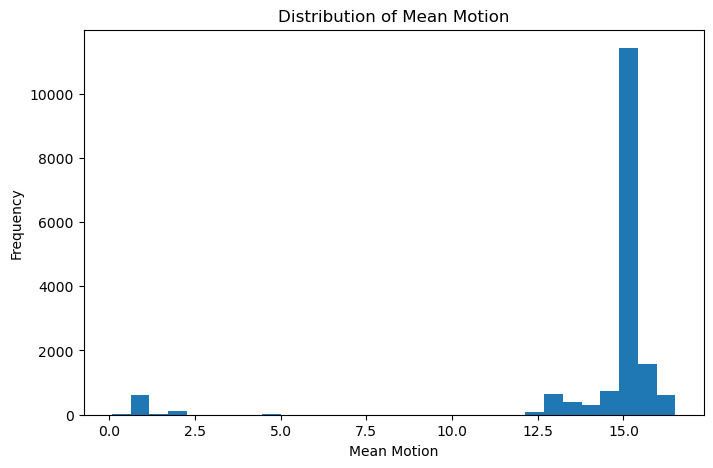

In [43]:
plt.figure(figsize=(8,5))

plt.hist(df["mean_motion"], bins=30)

plt.title("Distribution of Mean Motion")
plt.xlabel("Mean Motion")
plt.ylabel("Frequency")

plt.show()

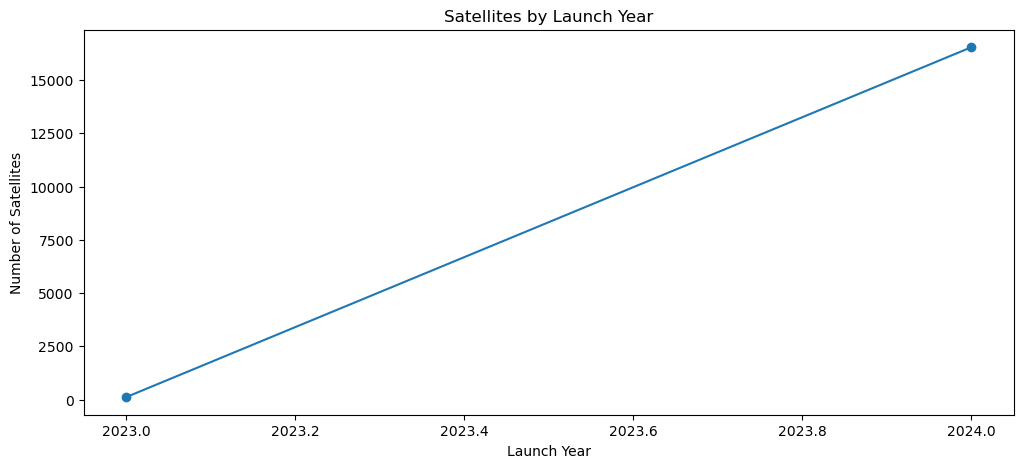

In [44]:
launch_counts = df["launch_year_estimate"].value_counts().sort_index()

plt.figure(figsize=(12,5))

plt.plot(launch_counts.index,
         launch_counts.values,
         marker="o")

plt.title("Satellites by Launch Year")
plt.xlabel("Launch Year")
plt.ylabel("Number of Satellites")

plt.show()

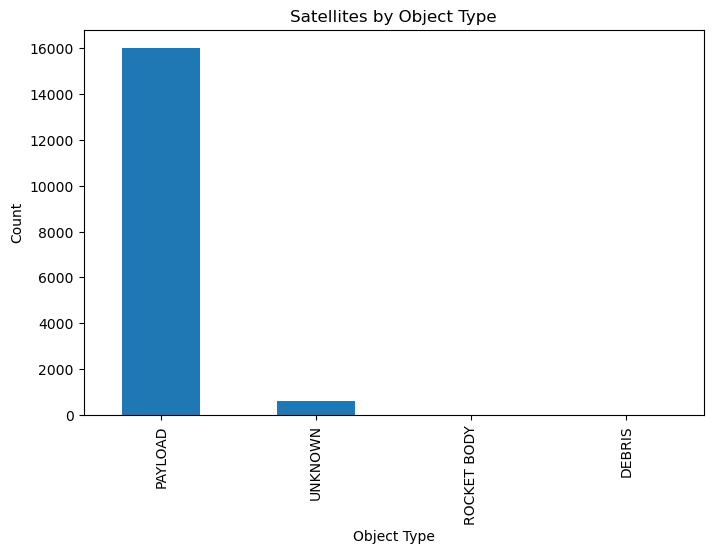

In [45]:
object_counts = df["object_type"].value_counts()

plt.figure(figsize=(8,5))

object_counts.plot(kind="bar")

plt.title("Satellites by Object Type")
plt.xlabel("Object Type")
plt.ylabel("Count")

plt.show()

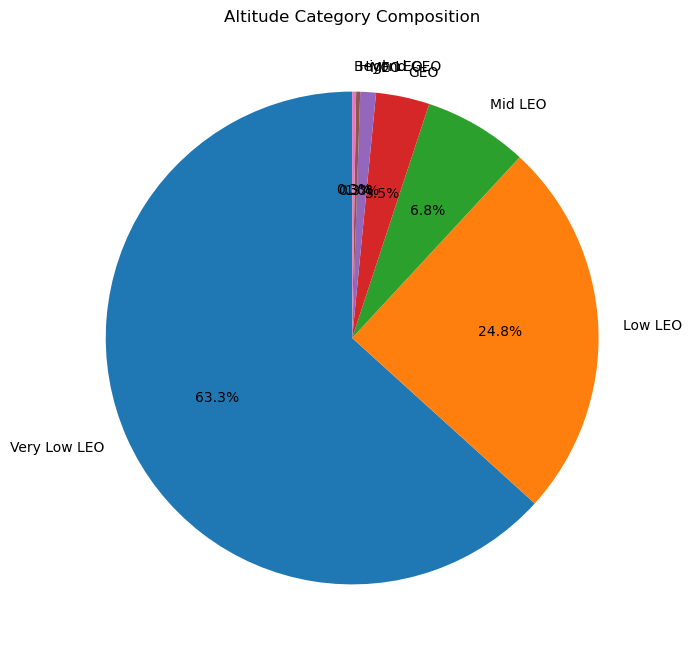

In [46]:
altitude_counts = df["altitude_category"].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    altitude_counts,
    labels=altitude_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Altitude Category Composition")

plt.show()

# Dataset Insights

## Insight 1
The majority of satellites belong to the **Very Low LEO** altitude category, accounting for approximately **63%** of the dataset.

## Insight 2
The **United States (US)** has the highest number of satellites in the dataset, followed by **PRC** and the **United Kingdom**.

## Insight 3
The distribution of **mean_motion** is concentrated within a specific range, while a small number of satellites were identified as outliers using IQR and Z-score analysis.

## Insight 4
Most objects in the dataset are classified as **Payloads**, with fewer objects categorized as debris or rocket bodies.

## Insight 5
Satellite launches are distributed across multiple years, indicating continuous growth in satellite deployment over time.